In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
seed = 2
samples_path = "SemiVisJets/samples/"
data_path = f"SemiVisJets/data/data_seed{seed}"
n_context = 2

In [3]:
models = ['reweight','generate', 'context_weight']
CR_Data = {}
SR_Data = {}

for i in range(1, 11):
    for model in models:
        CR_Data[f'{model}_CR_Data{i:02d}'] = np.load(f"{samples_path}/{model}_MC{seed:02d}_Data{i:02d}_CR_samples.npz", allow_pickle=True)
        SR_Data[f'{model}_SR_Data{i:02d}'] = np.load(f"{samples_path}/{model}_MC{seed:02d}_Data{i:02d}_SR_samples.npz", allow_pickle=True)

In [4]:
samples_cr_dict = {}
samples_sr_dict = {}
weights_cr_dict = {}
weights_sr_dict = {}
# Target_Data = {}
for i in range(1, 11):
    samples_cr_dict[f'truth_Data{i:02d}'] = np.load(f"{data_path}/data_events_chunk{i:02d}.npz", allow_pickle=True)['data_events_cr'][:, n_context:]
    samples_sr_dict[f'truth_Data{i:02d}'] = np.load(f"{data_path}/data_events_chunk{i:02d}.npz", allow_pickle=True)['data_events_sr'][:, n_context:]
    weights_cr_dict[f'truth_Data{i:02d}'] = None
    weights_sr_dict[f'truth_Data{i:02d}'] = None
    for model in ['reweight', 'generate']:
        if model == 'reweight':
            samples_cr_dict[f'{model}_CR_Data{i:02d}'] = CR_Data[f'{model}_CR_Data{i:02d}']['mc_cr'][:, n_context:]
            samples_sr_dict[f'{model}_SR_Data{i:02d}'] = SR_Data[f'{model}_SR_Data{i:02d}']['mc_samples'][:, n_context:]
            weights_cr_dict[f'{model}_CR_Data{i:02d}'] = CR_Data[f'{model}_CR_Data{i:02d}']["w_cr"]
            weights_sr_dict[f'{model}_SR_Data{i:02d}'] = SR_Data[f'{model}_SR_Data{i:02d}']["w_sr"]
        elif model == 'generate':
            samples_cr_dict[f'{model}_CR_Data{i:02d}'] = CR_Data[f'{model}_CR_Data{i:02d}']['generate_cr']
            samples_sr_dict[f'{model}_SR_Data{i:02d}'] = SR_Data[f'{model}_SR_Data{i:02d}']['samples']
            weights_cr_dict[f'{model}_CR_Data{i:02d}'] = None
            weights_sr_dict[f'{model}_SR_Data{i:02d}'] = SR_Data[f'context_weight_SR_Data{i:02d}']["w_sr"]

In [5]:
def plot_samples(samples, weights, bins, colors_dict, keys_to_plot, xlabel_list, bin_centers,
                 n_features, f1, f2, p=None, save_path=None, title="MC vs Data Comparison"):

    # print(colors_dict)

    # Ignore divide/invalid warnings
    np.seterr(divide='ignore', invalid='ignore')

    # Create figure with two rows (hist + ratio)
    fig, ax = plt.subplots(2, n_features, figsize=(5 * n_features, 1.5 * n_features),
                           gridspec_kw={'height_ratios': [2, 1]})

    for i in range(n_features):
        ax_top = ax[0, i]
        ax_bottom = ax[1, i]

        # Plot truth histogram first
        truth_key = f"truth_Data{p:02d}"  # pick the truth dataset for this chunk
        truth_vals = samples[truth_key][:, i]
        truth_vals = truth_vals[np.isfinite(truth_vals)]
        truth_density, _, _ = ax_top.hist(
            truth_vals,
            bins=bins,
            color=colors_dict[truth_key],
            label="Truth",
            density=True
        )

        # Compute histogram counts for error propagation
        hist_denom, _ = np.histogram(truth_vals, bins=bins)
        errors_denom = np.sqrt(hist_denom)

        # print(keys_to_plot, i)
        # Plot other datasets
        for k in keys_to_plot:
        
            loc_vals = samples[k][:, i]
            # print(k, loc_vals.shape)
            loc_vals = loc_vals[np.isfinite(loc_vals)]
            loc_w = weights[k] if weights[k] is not None else None
            # print(k, loc_w.shape if loc_w is not None else None)

            loc_density, _, _ = ax_top.hist(
                loc_vals,
                bins=bins,
                label=k,
                histtype="step",
                density=True,
                color=colors_dict[k],
                lw=2,
                weights=loc_w
            )

            # Ratio and error propagation
            loc_hist, _ = np.histogram(loc_vals, bins=bins, weights=loc_w)
            loc_errors = np.sqrt(loc_hist)
            # Avoid division by zero
            ratio = np.divide(loc_density, truth_density, out=np.zeros_like(loc_density), where=truth_density>0)
            errors_ratio = np.zeros_like(ratio)
            mask = (hist_denom > 0) & (loc_hist > 0)
            errors_ratio[mask] = ratio[mask] * np.sqrt((errors_denom[mask]/hist_denom[mask])**2 +
                                                       (loc_errors[mask]/loc_hist[mask])**2)
            ax_bottom.errorbar(bin_centers, ratio, yerr=errors_ratio, fmt='o', color=colors_dict[k], capsize=2)

        # Axis labels and limits
        ax_bottom.set_xlabel(xlabel_list[i], fontsize=f1)
        ax_bottom.set_ylabel("Ratio to truth", fontsize=f1)
        ax_bottom.axhline(1, color='black', linestyle='dashed')
        ax_bottom.set_xlim(bins[0], bins[-1])
        ax_bottom.set_ylim(0, 2)
        ax_top.set_xlim(bins[0], bins[-1])
        ax_top.set_ylabel("a.u.", fontsize=f1)
        ax_top.set_yticks([])

    # Remove y-ticks for ratio except first
    for i in range(1, n_features):
        ax[1, i].set_yticks([])

    # Legend
    ax[0, 0].legend(frameon=False, fontsize=f2)

    # Main figure title
    fig.suptitle(f"{title} - Data Chunk {p}" if p is not None else title, fontsize=f1, fontweight='bold')

    # Layout
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    # Save if path provided
    if save_path is not None:
        plt.savefig(save_path, format="pdf", bbox_inches="tight")

    plt.show()


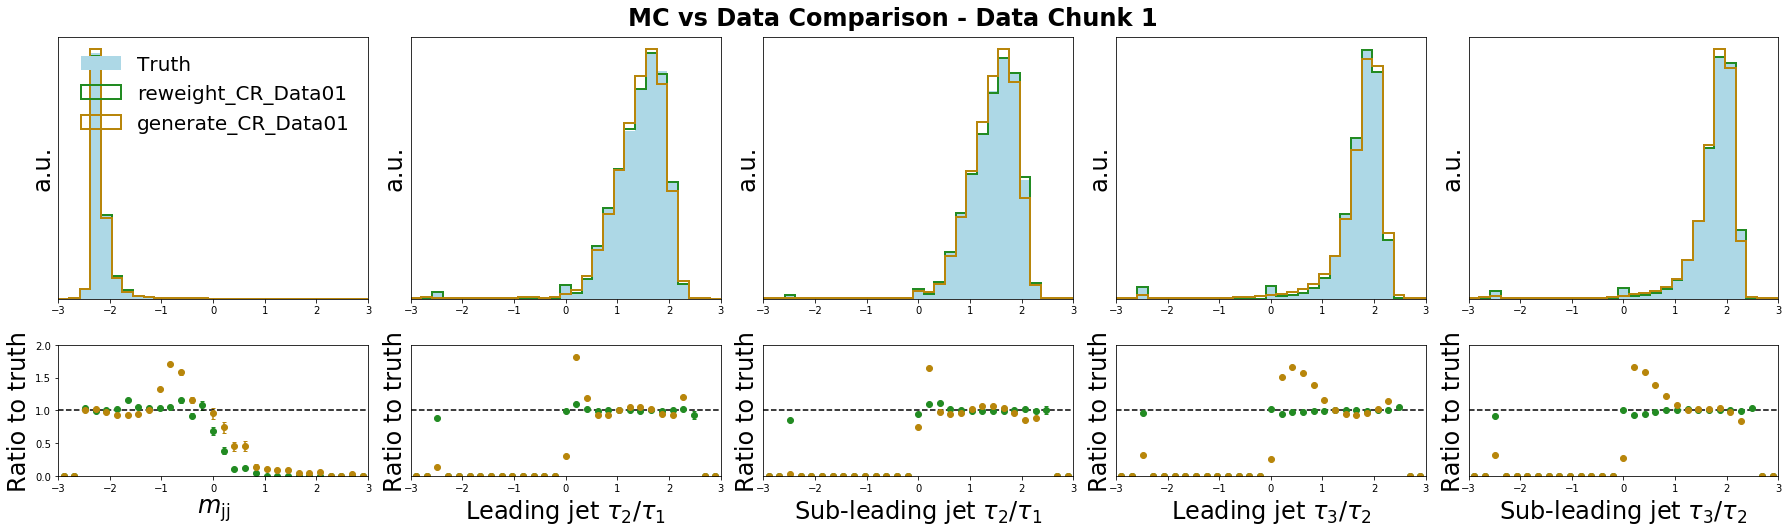

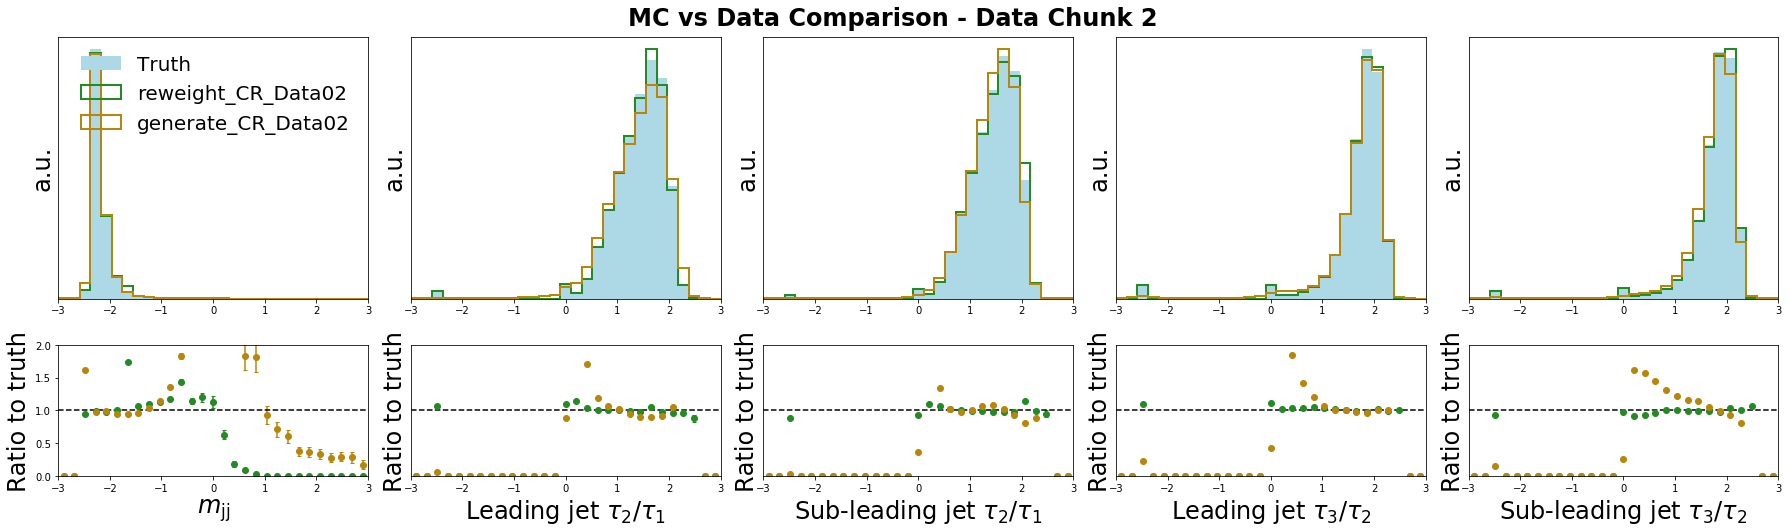

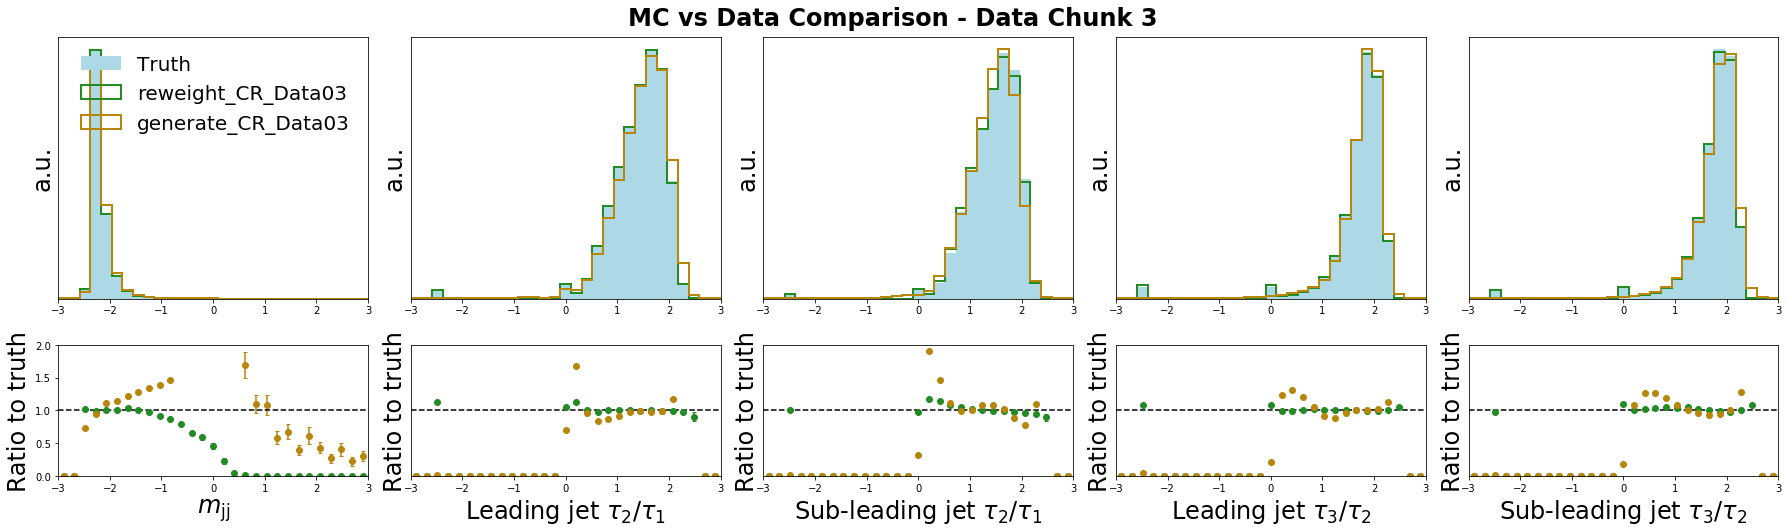

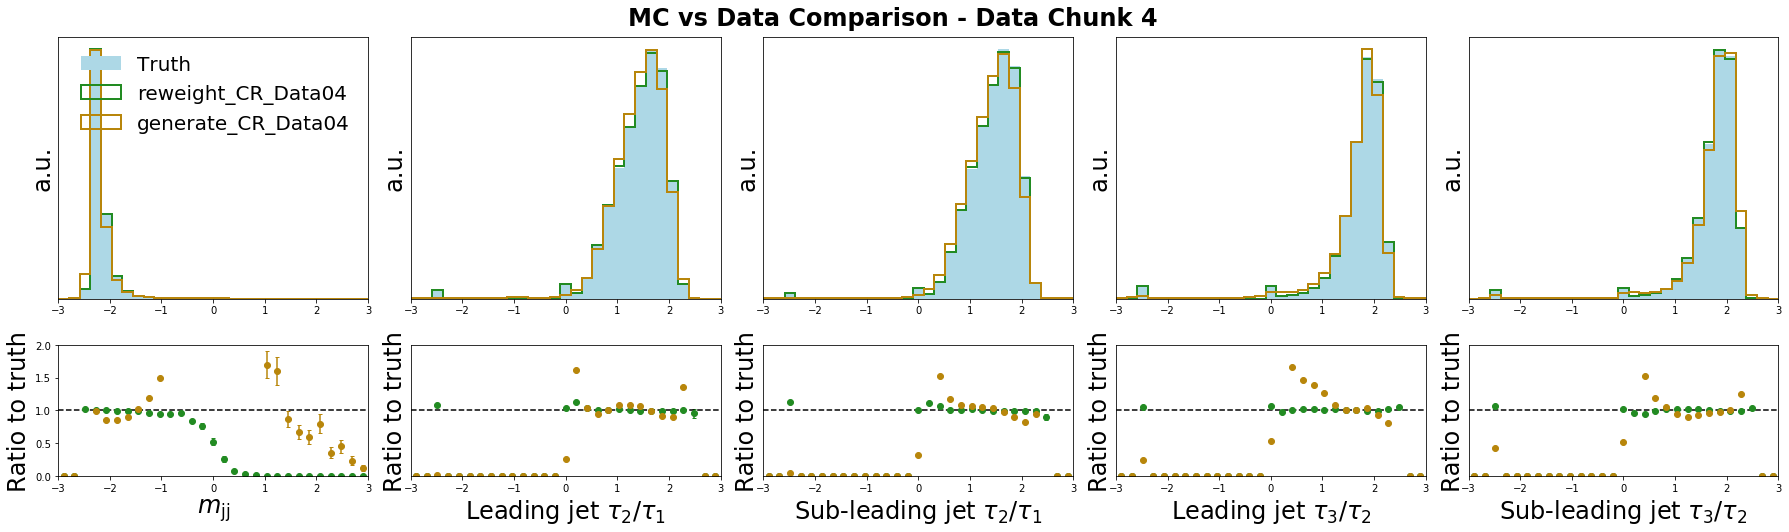

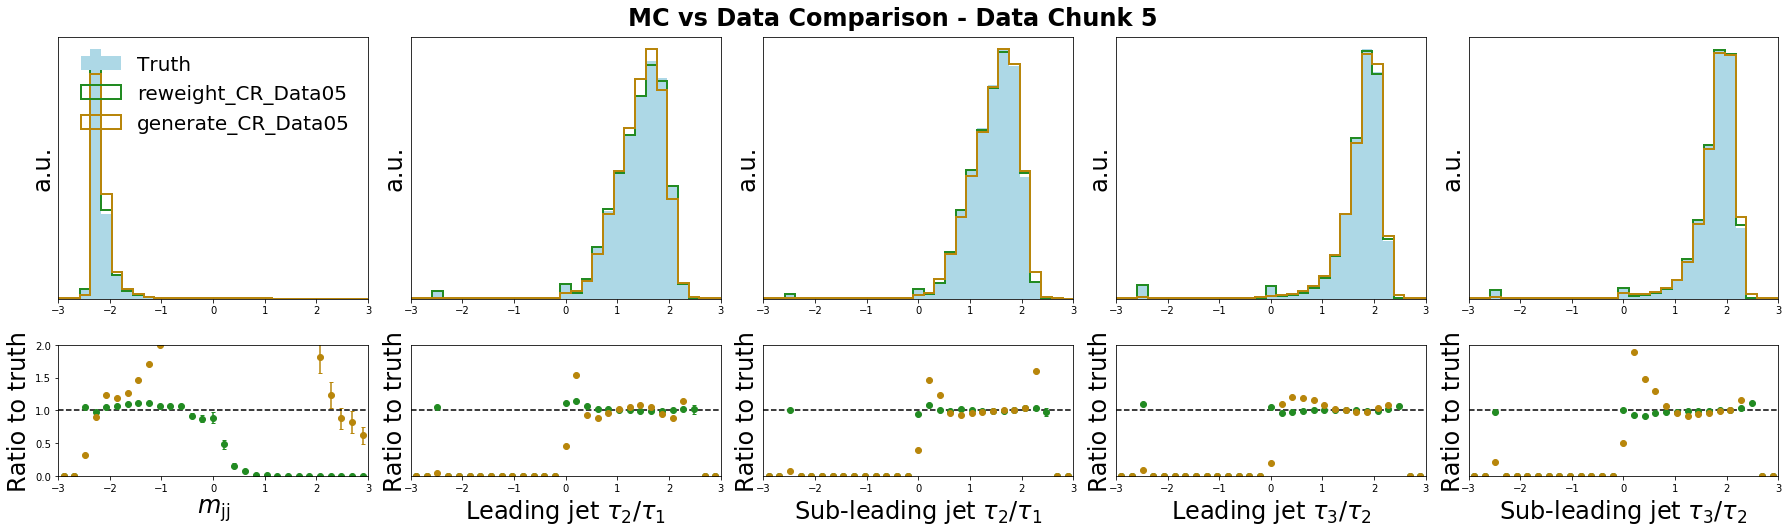

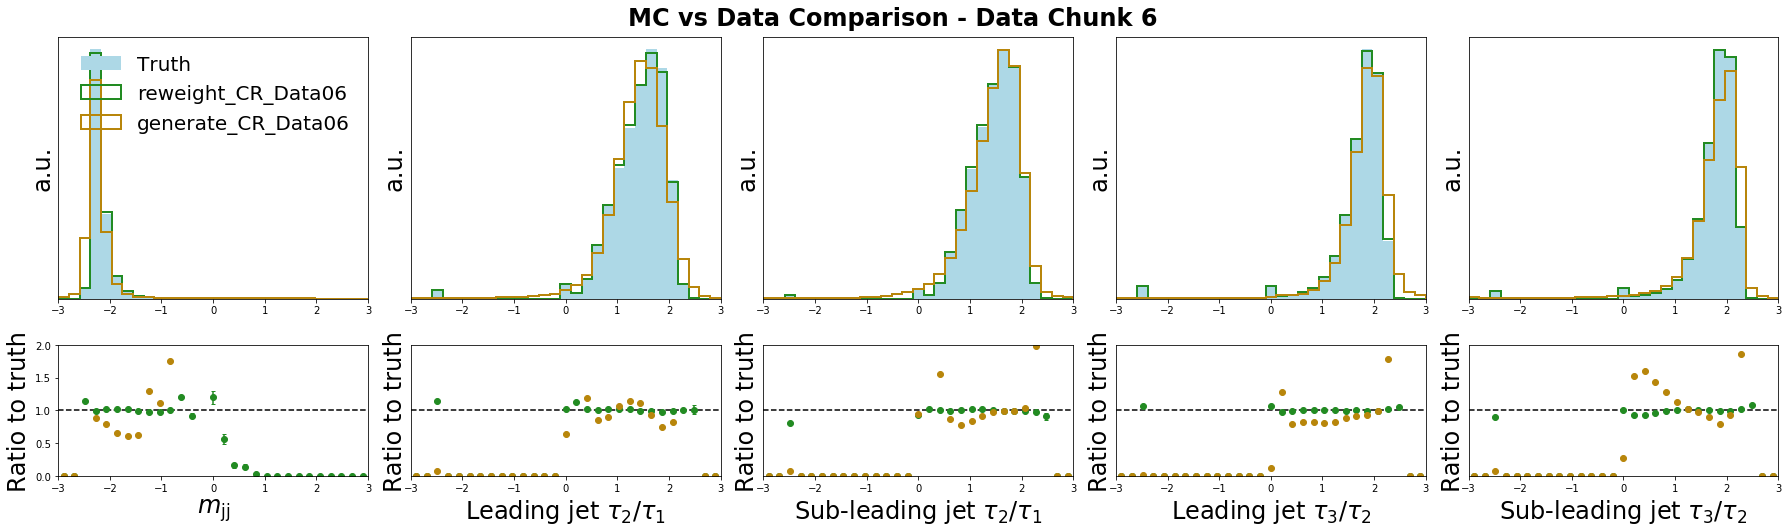

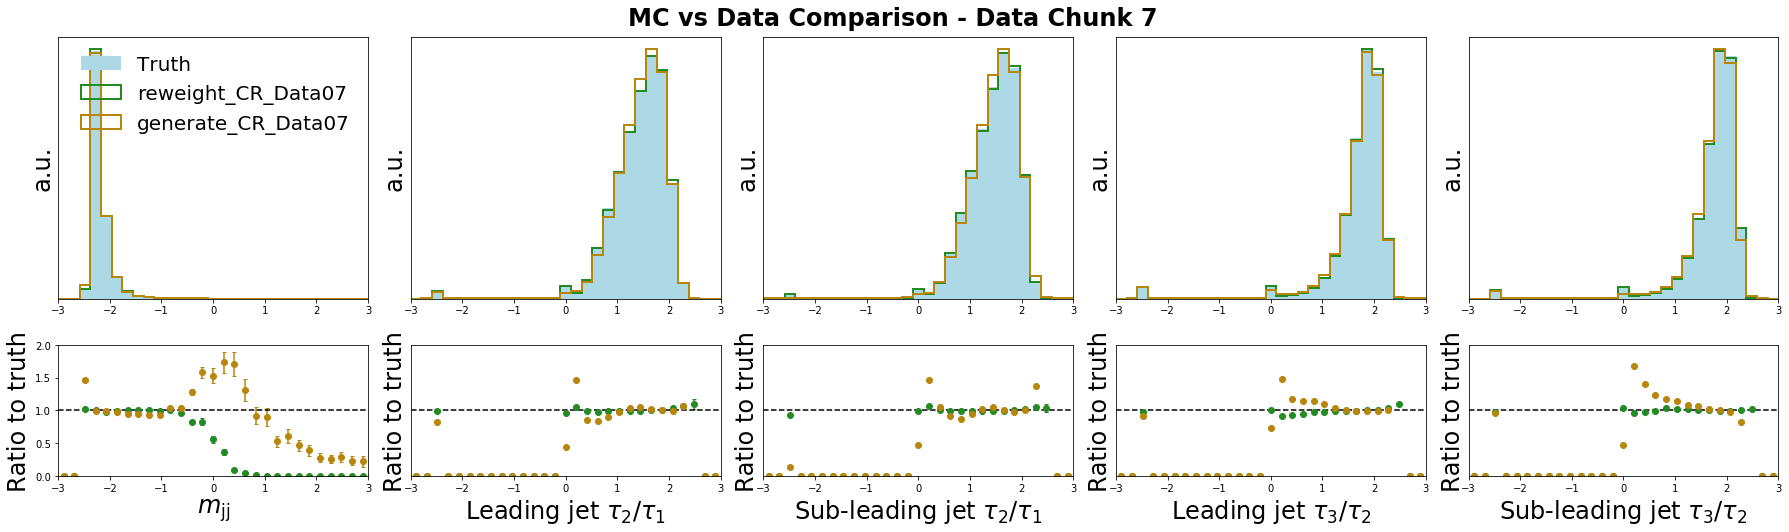

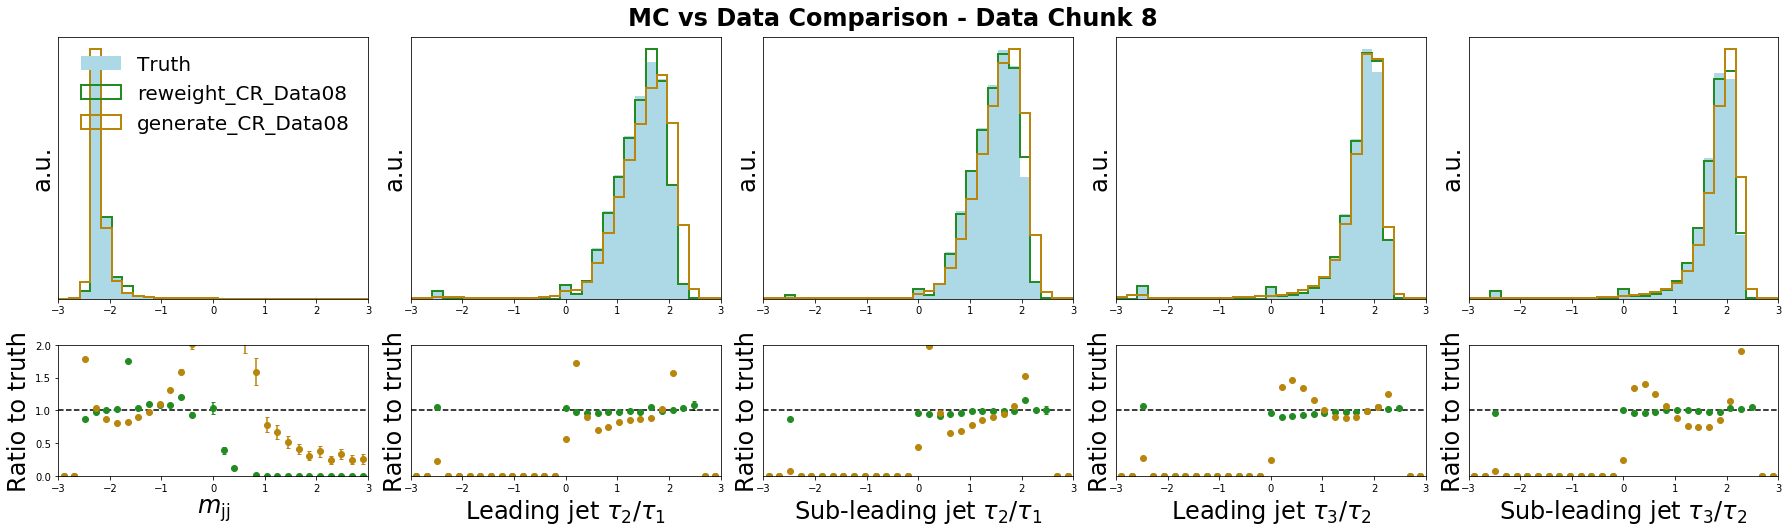

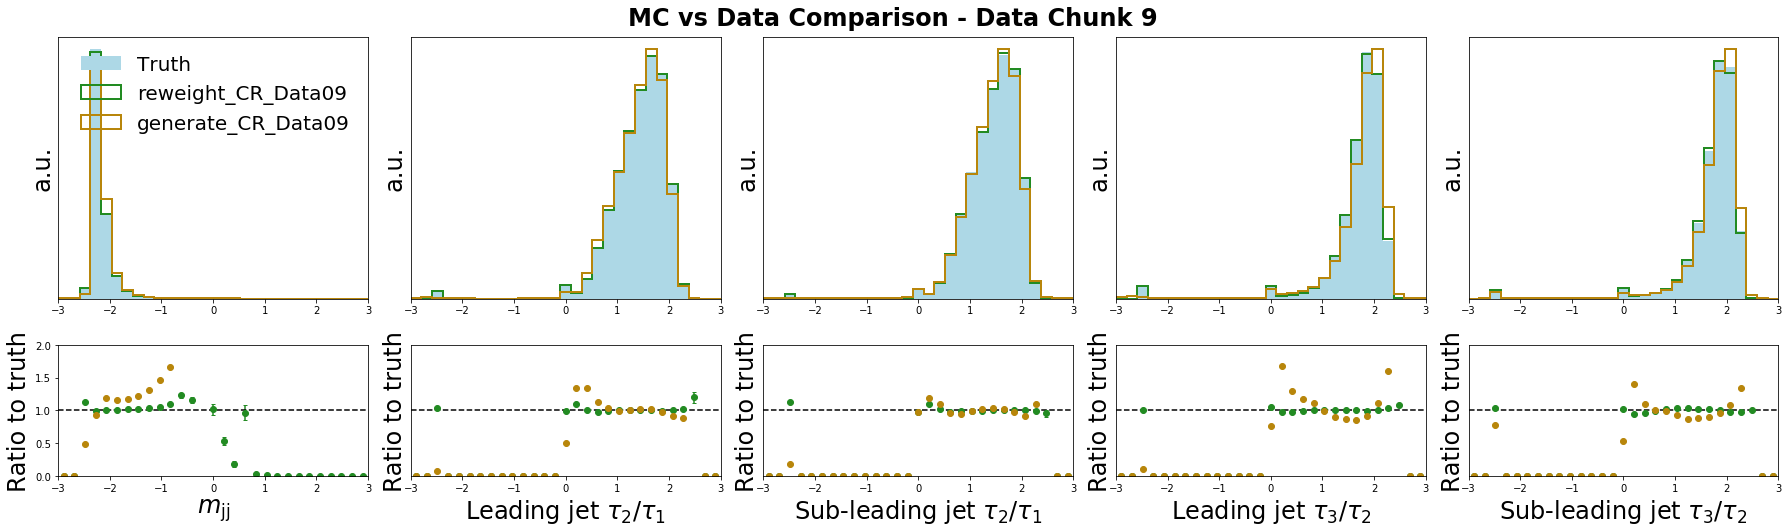

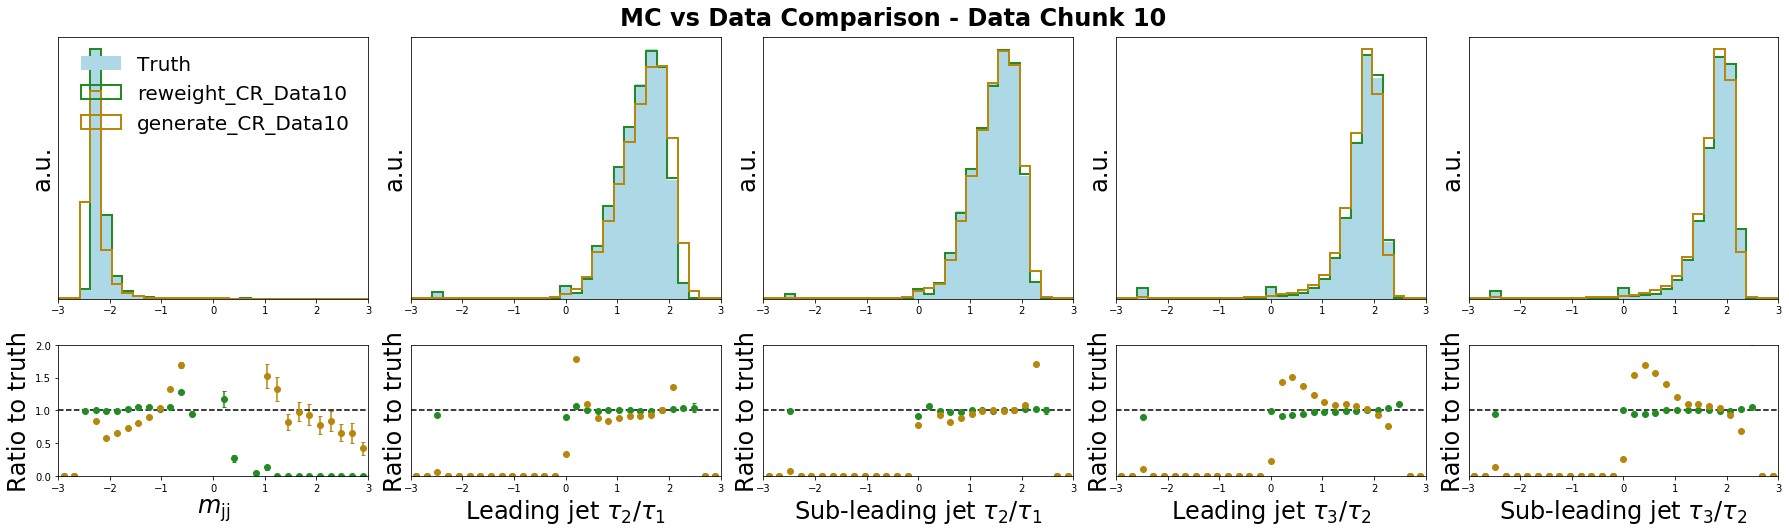

In [6]:
#Graph Part
#Labels and stuff
def name_map():
    return {
        "m_jj": "$m_{{\\rm jj}}$",
        "met": "MET",
        "ht": "HT",
        "pT_j1": "Leading jet $p_{{\\rm T}}$",
        "pT_j2": "Sub-leading jet $p_{{\\rm T}}$",
        "tau21_j1": "Leading jet $\\tau_2/\\tau_1$",
        "tau21_j2": "Sub-leading jet $\\tau_2/\\tau_1$",
        "tau32_j1": "Leading jet $\\tau_3/\\tau_2$",
        "tau32_j2": "Sub-leading jet $\\tau_3/\\tau_2$",
        "min_dPhi": "min$\\Delta\\phi(\\rm j_i, \\rm MET)$",
    }

var_names = ["m_jj", "tau21_j1", "tau21_j2", "tau32_j1", "tau32_j2"]
names = name_map()
xlabel_list = [names[x] for x in var_names]
bins = np.linspace(-3, 3, 30)
bin_centers = 0.5 * (bins[1:] + bins[:-1])
colors_dict_samples = {
    "reweight": "forestgreen",
    "generate": "darkgoldenrod",
    "truth": "lightblue"
}
f1, f2 = 24, 20
n_features = len(var_names)

for i in range(1, 11):
    truth_key = f"truth_Data{i:02d}"
    keys_to_plot = ["reweight_CR_Data{:02d}".format(i), "generate_CR_Data{:02d}".format(i)]
    keys_to_plot = [f"reweight_CR_Data{i:02d}", f"generate_CR_Data{i:02d}"]

    colors_dict_i = {
        truth_key: "lightblue",
        f"reweight_CR_Data{i:02d}": "forestgreen",
        f"generate_CR_Data{i:02d}": "darkgoldenrod"
    }
    plot_samples(
        samples_cr_dict,
        weights_cr_dict,
        bins,
        colors_dict_i,
        keys_to_plot,
        xlabel_list,
        bin_centers,
        n_features,
        f1,
        f2,
        p=i,  # optional, just for naming inside function
        # save_path=save_path
    )


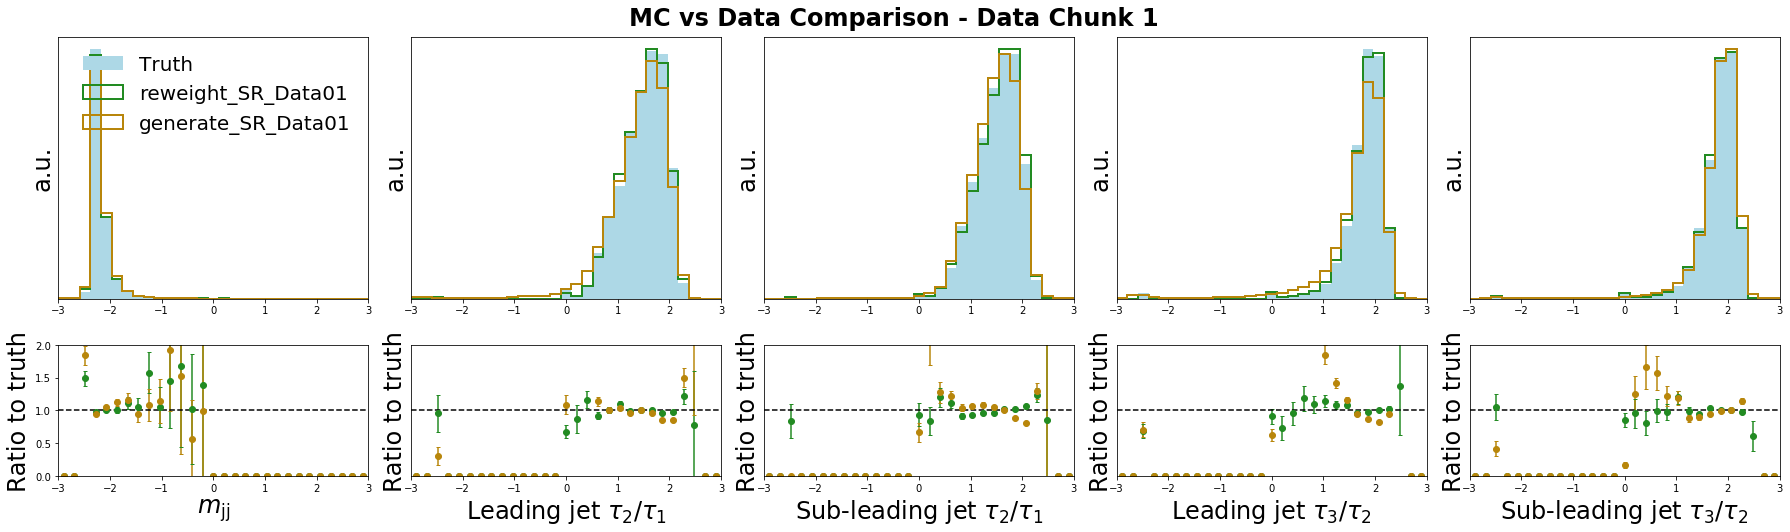

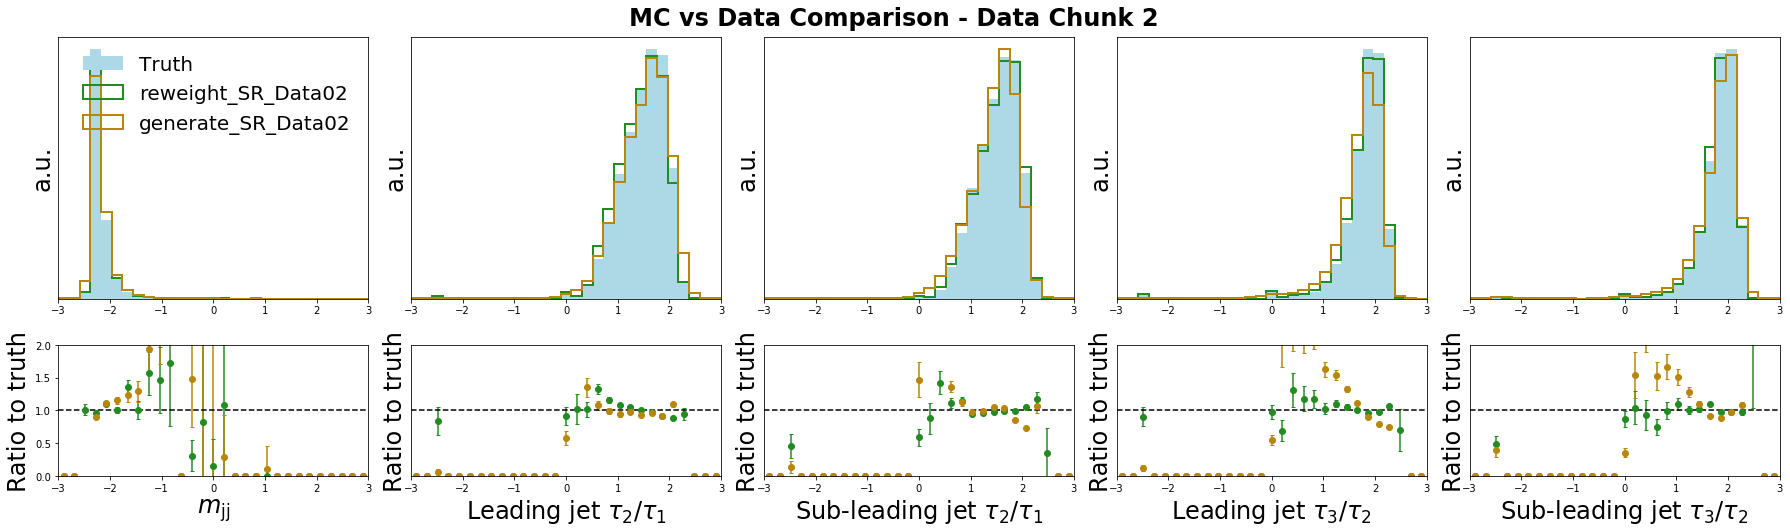

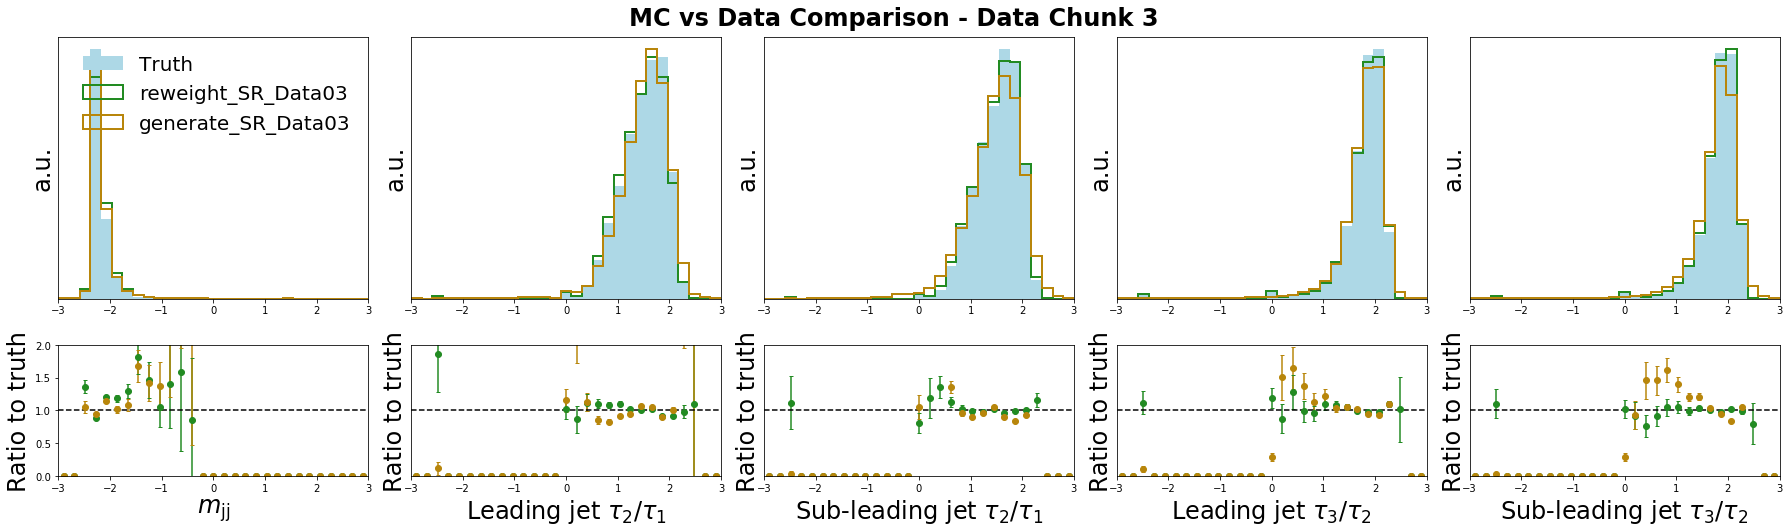

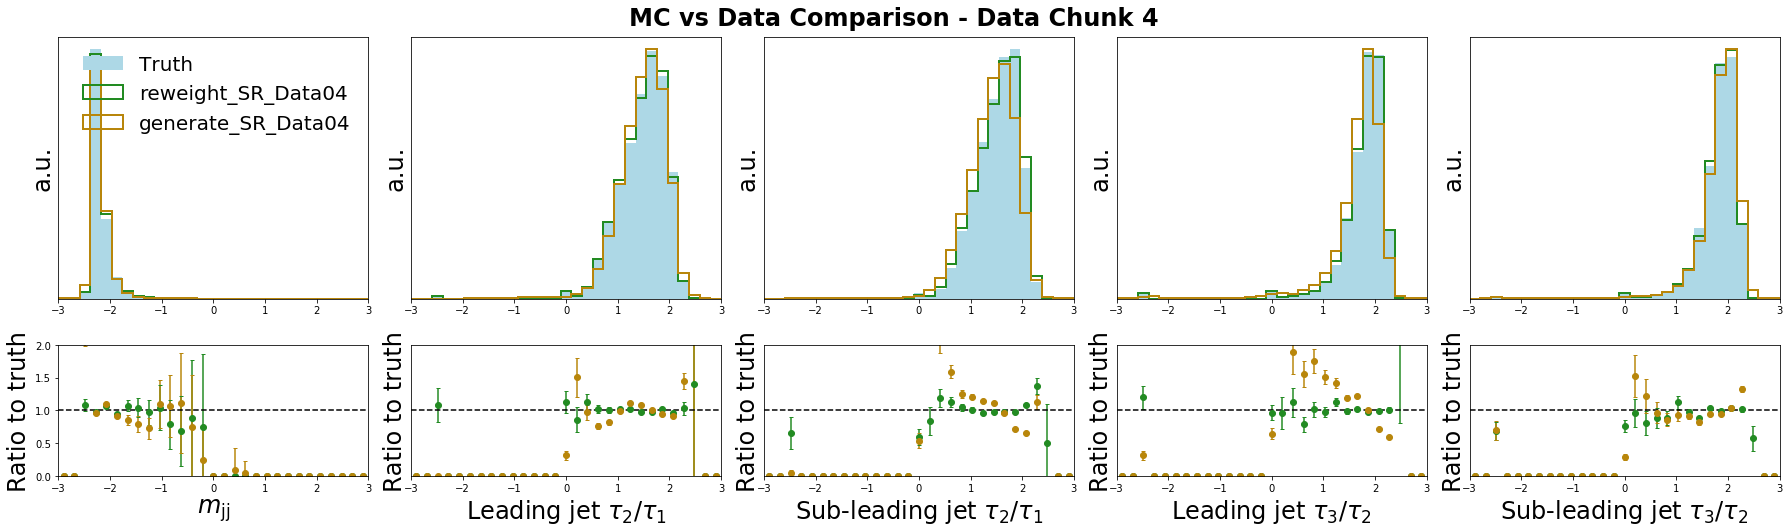

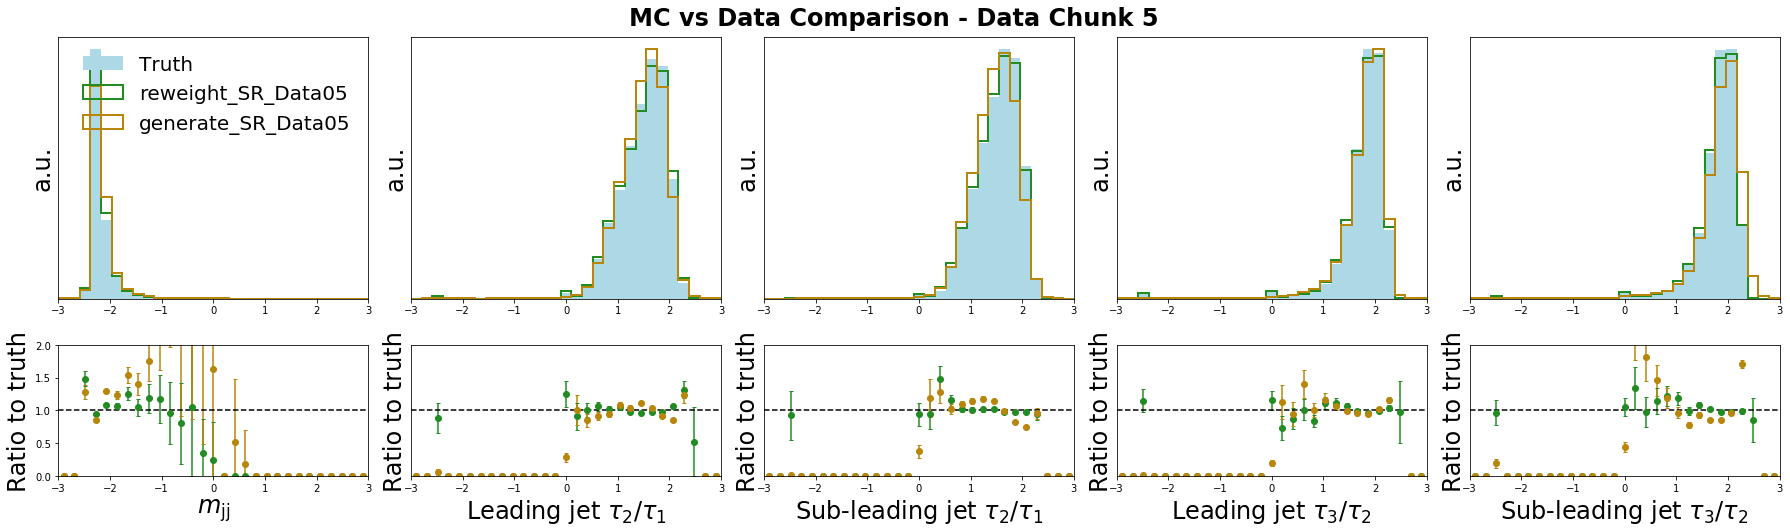

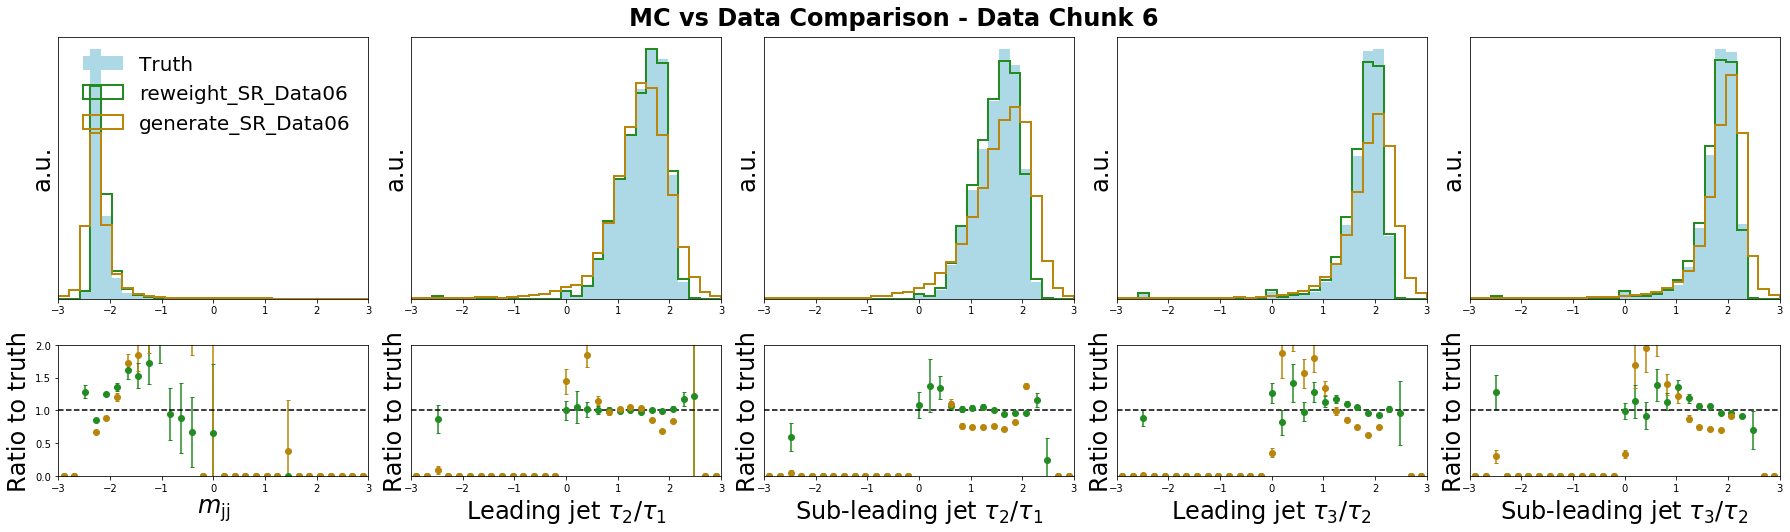

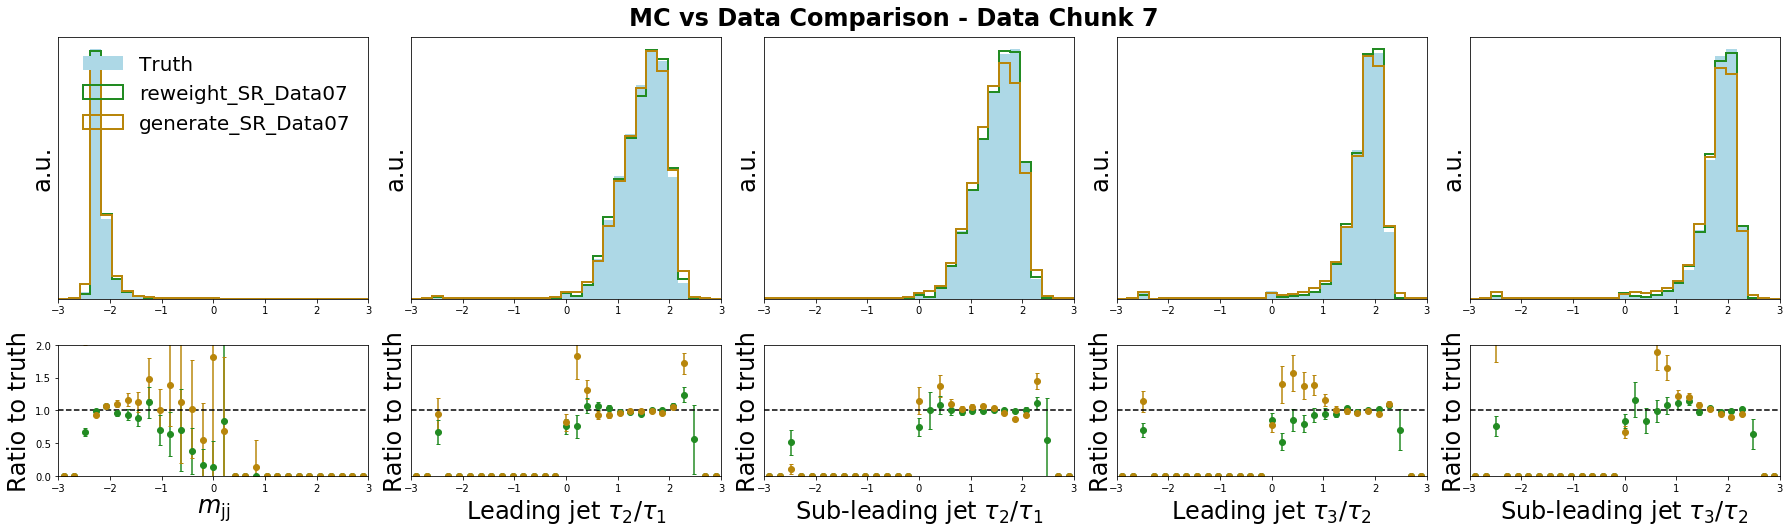

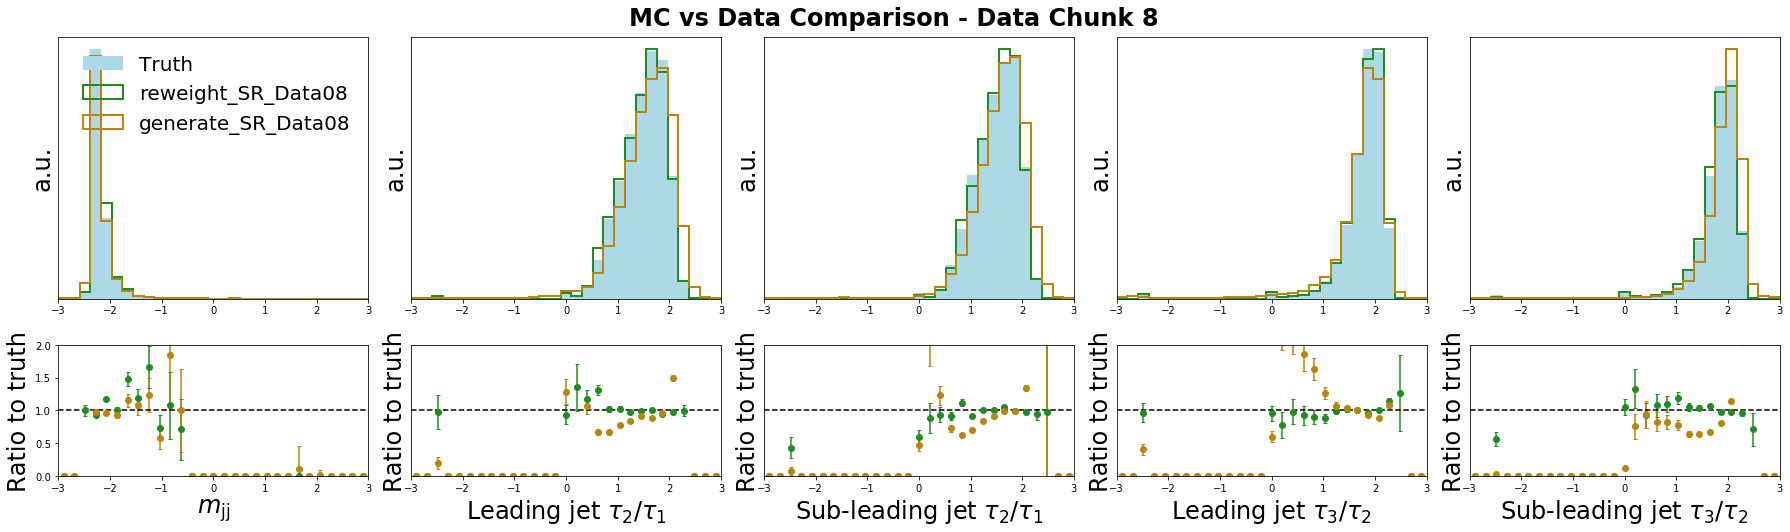

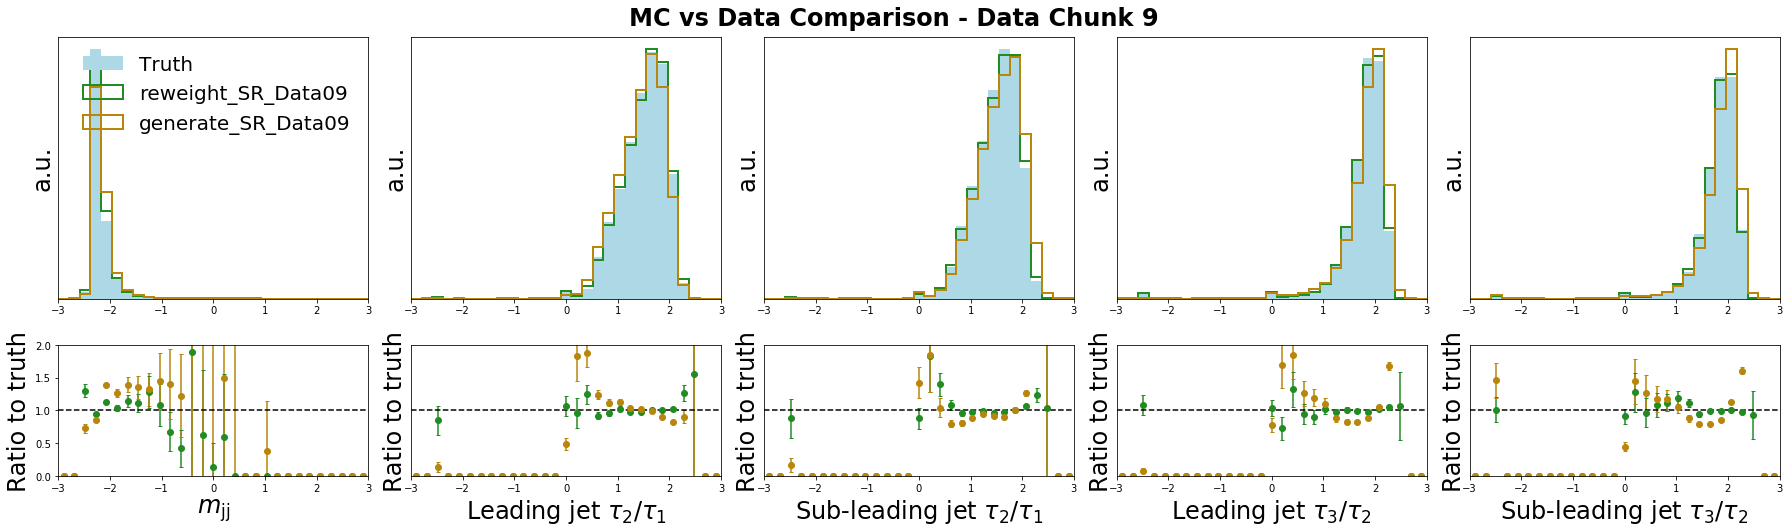

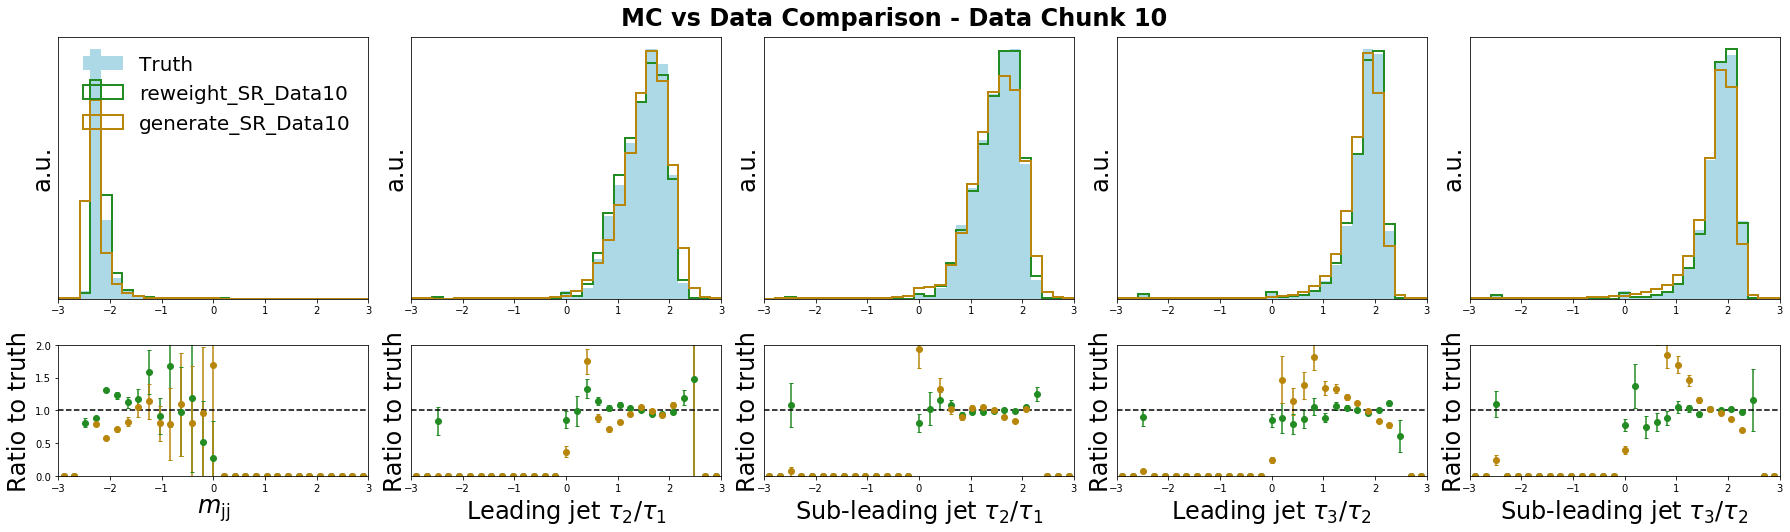

In [7]:
def name_map():
    return {
        "m_jj": "$m_{{\\rm jj}}$",
        "met": "MET",
        "ht": "HT",
        "pT_j1": "Leading jet $p_{{\\rm T}}$",
        "pT_j2": "Sub-leading jet $p_{{\\rm T}}$",
        "tau21_j1": "Leading jet $\\tau_2/\\tau_1$",
        "tau21_j2": "Sub-leading jet $\\tau_2/\\tau_1$",
        "tau32_j1": "Leading jet $\\tau_3/\\tau_2$",
        "tau32_j2": "Sub-leading jet $\\tau_3/\\tau_2$",
        "min_dPhi": "min$\\Delta\\phi(\\rm j_i, \\rm MET)$",
    }

var_names = ["m_jj", "tau21_j1", "tau21_j2", "tau32_j1", "tau32_j2"]
names = name_map()
xlabel_list = [names[x] for x in var_names]
bins = np.linspace(-3, 3, 30)
bin_centers = 0.5 * (bins[1:] + bins[:-1])
colors_dict_samples = {
    "reweight": "forestgreen",
    "generate": "darkgoldenrod",
    "truth": "lightblue"
}
f1, f2 = 24, 20
n_features = len(var_names)
for i in range(1, 11):
    truth_key = f"truth_Data{i:02d}"
    keys_to_plot = ["reweight_SR_Data{:02d}".format(i), "generate_SR_Data{:02d}".format(i)]
    keys_to_plot = [f"reweight_SR_Data{i:02d}", f"generate_SR_Data{i:02d}"]

    colors_dict_i = {
        truth_key: "lightblue",
        f"reweight_SR_Data{i:02d}": "forestgreen",
        f"generate_SR_Data{i:02d}": "darkgoldenrod"
    }
    plot_samples(
        samples_sr_dict,
        weights_sr_dict,
        bins,
        colors_dict_i,
        keys_to_plot,
        xlabel_list,
        bin_centers,
        n_features,
        f1,
        f2,
        p=i,  # optional, just for naming inside function
        # save_path=save_path
    )

In [8]:
# from scipy.stats import wasserstein_distancee

# # def plot_wasserstein_distances(distances, models, feature, data_num):
#     """
#     Plots a bar chart of Wasserstein distances for three models, including additional statistics.

#     Parameters:
#     distances (list of float): Wasserstein distances for three models
#     models (list of str): Corresponding model names (should be exactly three)
#     """
#     # if len(models) != 3 or len(distances) != 3:
#     #     raise ValueError("This function is designed for exactly three models.")
    
#     # Compute statistics
#     avg_distance = np.mean(distances)
#     min_distance = np.min(distances)
#     max_distance = np.max(distances)
    
#     plt.figure(figsize=(8, 6))
#     bars = plt.bar(models, distances, color=['royalblue', 'seagreen', 'tomato'], alpha=0.85, edgecolor='black', linewidth=1.5)
    
#     plt.xlabel("Models", fontsize=14, fontweight='bold')
#     plt.ylabel("Wasserstein Distance", fontsize=14, fontweight='bold')
#     plt.title(f"Wasserstein Distance Comparison for {feature} on Data{data_num:02d}", fontsize=16, fontweight='bold')
    
#     # Display values inside bars with improved styling
#     for bar, value in zip(bars, distances):
#         plt.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2, 
#                  str(round(value, 3)), ha='center', va='center', fontsize=14, fontweight='bold', color='white')
    
#     # Plot average line
#     plt.axhline(avg_distance, color='orange', linestyle='dashed', linewidth=2, label=f'Avg: {avg_distance:.3f}')
#     # plt.axhline(min_distance, color='gray', linestyle='dotted', linewidth=1.5, label=f'Min: {min_distance:.3f}')
#     # plt.axhline(max_distance, color='purple', linestyle='dotted', linewidth=1.5, label=f'Max: {max_distance:.3f}')
    
#     # Add legend
#     plt.legend(loc='upper right', fontsize=12, frameon=True, facecolor='white', edgecolor='black')
    
#     # Beautify the plot
#     plt.grid(axis='y', linestyle='--', alpha=0.7)
#     plt.xticks(fontsize=12, fontweight='bold')
#     plt.yticks(fontsize=12, fontweight='bold')
#     plt.tight_layout()
    
#     plt.show()

In [9]:
models = ['reweight', 'generate']
var_names = ["m_jj", "tau21_j1", "tau21_j2", "tau32_j1", "tau32_j2"]
wasser_distances_cr = {}
wasser_distances_sr = {}
for i in range(1, 11):
    for feature in var_names:
        wasser_distances_cr[f"{feature}_wasdis_Data{i:02d}"] = []
        wasser_distances_sr[f"{feature}_wasdis_Data{i:02d}"] = []

In [10]:
from scipy.stats import wasserstein_distance
import numpy as np

n_to_use = 9_900_000
clip_range = (-2.5, 2.5)  # same as preprocessing range

for j in range(1, 11):
    for model in models:
        u_key = f"{model}_CR_Data{j:02d}"
        truth_key = f"truth_Data{j:02d}"

        u_values_all = samples_cr_dict[u_key][:n_to_use, :].T
        v_values_all = samples_cr_dict[truth_key][:n_to_use, :].T

        # Clip outliers (generator explosion)
        u_values_all = np.clip(u_values_all, *clip_range)
        v_values_all = np.clip(v_values_all, *clip_range)

        # Get weights
        u_weights_all = weights_cr_dict.get(u_key, None)
        if u_weights_all is not None:
            u_weights_all = u_weights_all[:n_to_use]
            u_weights_all /= np.sum(u_weights_all)
            u_weights_all = np.tile(u_weights_all, (u_values_all.shape[0], 1))
        else:
            u_weights_all = None

        # Compute Wasserstein distances
        for i, feature in enumerate(var_names):
            u_vals = u_values_all[i]
            v_vals = v_values_all[i]

            # Filter out any remaining non-finite values
            mask = np.isfinite(u_vals) & np.isfinite(v_vals)
            u_vals, v_vals = u_vals[mask], v_vals[mask]

            if u_weights_all is None:
                wd = wasserstein_distance(u_vals, v_vals)
            else:
                wd = wasserstein_distance(u_vals, v_vals, u_weights=u_weights_all[i][mask])

            wasser_distances_cr[f"{feature}_wasdis_Data{j:02d}"].append(wd)
            print(f"[{u_key}] {feature}: WD = {wd:.4e}")


[reweight_CR_Data01] m_jj: WD = 4.3784e-03
[reweight_CR_Data01] tau21_j1: WD = 2.9594e-03
[reweight_CR_Data01] tau21_j2: WD = 3.8865e-03
[reweight_CR_Data01] tau32_j1: WD = 3.1196e-03
[reweight_CR_Data01] tau32_j2: WD = 3.8408e-03
[generate_CR_Data01] m_jj: WD = 5.8942e-03
[generate_CR_Data01] tau21_j1: WD = 1.5300e-02
[generate_CR_Data01] tau21_j2: WD = 1.9198e-02
[generate_CR_Data01] tau32_j1: WD = 2.7658e-02
[generate_CR_Data01] tau32_j2: WD = 1.8083e-02
[reweight_CR_Data02] m_jj: WD = 1.1151e-02
[reweight_CR_Data02] tau21_j1: WD = 8.1640e-03
[reweight_CR_Data02] tau21_j2: WD = 6.2979e-03
[reweight_CR_Data02] tau32_j1: WD = 1.1910e-02
[reweight_CR_Data02] tau32_j2: WD = 7.4520e-03
[generate_CR_Data02] m_jj: WD = 6.8621e-03
[generate_CR_Data02] tau21_j1: WD = 7.0255e-02
[generate_CR_Data02] tau21_j2: WD = 2.6984e-02
[generate_CR_Data02] tau32_j1: WD = 3.8770e-02
[generate_CR_Data02] tau32_j2: WD = 3.9776e-02
[reweight_CR_Data03] m_jj: WD = 1.9266e-03
[reweight_CR_Data03] tau21_j1: WD

In [11]:
from scipy.stats import wasserstein_distance
import numpy as np

# n_to_use = 16256
clip_range = (-2.5, 2.5)  # same as preprocessing range

for j in range(1, 11):
    for model in models:
        u_key = f"{model}_SR_Data{j:02d}"
        truth_key = f"truth_Data{j:02d}"

        v_values_all = samples_sr_dict[truth_key][:, :].T
        n_to_use = samples_sr_dict[truth_key].shape[0]
        u_values_all = samples_sr_dict[u_key][:n_to_use, :].T
        

        print(f"Data{j:02d}", u_values_all.shape, v_values_all.shape)

        # Clip outliers (generator explosion)
        u_values_all = np.clip(u_values_all, *clip_range)
        v_values_all = np.clip(v_values_all, *clip_range)

        # Get weights
        u_weights_all = weights_sr_dict.get(u_key, None)
        if u_weights_all is not None:
            u_weights_all = u_weights_all[:n_to_use]
            u_weights_all /= np.sum(u_weights_all)
            u_weights_all = np.tile(u_weights_all, (u_values_all.shape[0], 1))
        else:
            u_weights_all = None

        # Compute Wasserstein distances
        for i, feature in enumerate(var_names):
            u_vals = u_values_all[i]
            v_vals = v_values_all[i]

            # Filter out any remaining non-finite values
            mask = np.isfinite(u_vals) & np.isfinite(v_vals)
            u_vals, v_vals = u_vals[mask], v_vals[mask]

            if u_weights_all is None:
                wd = wasserstein_distance(u_vals, v_vals)
            else:
                wd = wasserstein_distance(u_vals, v_vals, u_weights=u_weights_all[i][mask])

            wasser_distances_sr[f"{feature}_wasdis_Data{j:02d}"].append(wd)
            print(f"[{u_key}] {feature}: WD = {wd:.4e}")


Data01 (5, 16256) (5, 16256)
[reweight_SR_Data01] m_jj: WD = 6.6408e-03
[reweight_SR_Data01] tau21_j1: WD = 6.7178e-03
[reweight_SR_Data01] tau21_j2: WD = 1.6972e-02
[reweight_SR_Data01] tau32_j1: WD = 1.2282e-02
[reweight_SR_Data01] tau32_j2: WD = 6.4844e-03
Data01 (5, 16256) (5, 16256)
[generate_SR_Data01] m_jj: WD = 1.1350e-02
[generate_SR_Data01] tau21_j1: WD = 9.0787e-02
[generate_SR_Data01] tau21_j2: WD = 3.7501e-02
[generate_SR_Data01] tau32_j1: WD = 1.4982e-01
[generate_SR_Data01] tau32_j2: WD = 1.9095e-02
Data02 (5, 16059) (5, 16059)
[reweight_SR_Data02] m_jj: WD = 1.1137e-02
[reweight_SR_Data02] tau21_j1: WD = 2.6513e-02
[reweight_SR_Data02] tau21_j2: WD = 1.0229e-02
[reweight_SR_Data02] tau32_j1: WD = 1.0101e-02
[reweight_SR_Data02] tau32_j2: WD = 1.6193e-02
Data02 (5, 16059) (5, 16059)
[generate_SR_Data02] m_jj: WD = 2.3472e-02
[generate_SR_Data02] tau21_j1: WD = 3.8943e-02
[generate_SR_Data02] tau21_j2: WD = 7.4757e-02
[generate_SR_Data02] tau32_j1: WD = 1.1732e-01
[genera

In [12]:
# for i in range(1, 11):
#     print("Data chunk", i)
#     for feature in var_names:
#         # print((wasser_distances_cr[f"{feature}_wasdis"]))
#         # plot_wasserstein_distances(wasser_distances_sr[f"{feature}_wasdis_Data{i:02d}"], models, feature, i)
#         # print(feature, wasser_distances_cr[f"{feature}_wasdis_Data{i:02d}"])
    